Import the necassary libraries, including pandas, numpy, matplotlib, and seaborn, as well as loading the dataset we will use for the analysis.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('imdb_movies.csv')

This cell initialises the data inspection to understand the structure of the dataset and identify any issues.

In [51]:
print('----------Head----------')
print(df.head())
print('----------Info----------')
print(df.info())
print('----------Describe----------')
print(df.describe())
print('----------isnull and sum----------')
print(df.isnull().sum())

----------Head----------
                         names       date_x  score  \
0                    Creed III  03/02/2023   73.00   
1     Avatar: The Way of Water  12/15/2022   78.00   
2  The Super Mario Bros. Movie  04/05/2023   76.00   
3                      Mummies  01/05/2023   70.00   
4                    Supercell  03/17/2023   61.00   

                                           genre  \
0                                  Drama, Action   
1             Science Fiction, Adventure, Action   
2  Animation, Adventure, Family, Fantasy, Comedy   
3  Animation, Comedy, Family, Adventure, Fantasy   
4                                         Action   

                                            overview  \
0  After dominating the boxing world, Adonis Cree...   
1  Set more than a decade after the events of the...   
2  While working underground to fix a water main,...   
3  Through a series of unfortunate events, three ...   
4  Good-hearted teenager William always lived in ...   



The orginal release date for films is a little confusing to understand, as it is written as 'date_x'. Therefore to aid in the analysis process, the name of this column is converted to 'release_date'.

In [53]:
df['release_date'] = pd.to_datetime(df['date_x'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month

The following cell prepares the 'genre' column for enhanced analysis by accomplishing the following:
* Replace non‑breaking spaces with regular spaces.
* Fill missing genre with "Unknown"
* Extract first listed genre in that column.

In [55]:
df['genre'] = df['genre'].astype(str).str.replace('\xa0', ' ')
df['genre'] = df['genre'].fillna("Unknown")
df['genre_first'] = df['genre'].apply(lambda x: x.split(",")[0].strip())

This code cell cleans any missing values in that appear in the 'crew' column.

In [57]:
df['crew'] = df['crew'].fillna("Unknown")

The DataFrame’s column names are updated for better readability. the original names column becomes title, budget_x is simplified to budget, and date_x is renamed to raw_release_date. This renaming aligns the dataset with common naming conventions, making subsequent analysis and code more intuitive, especially when referencing a movie’s title, its budget, or the raw release date. The change is performed with a single rename call

In [59]:
df = df.rename(columns={
    'names': 'title',
    'budget_x': 'budget',
    'date_x': 'raw_release_date'
})


Two financial features are created: profit, the difference between revenue and budget, and ROI (return on investment), the revenue‑to‑budget ratio. To prevent division‑by‑zero errors, any zero budgets are temporarily replaced with NaN.

In [61]:
df['profit'] = df['revenue'] - df['budget']
df['roi'] = df['revenue'] / df['budget'].replace(0, np.nan)

To keep only movies whose production budget exceeds 1,000, filter the DataFrame with a boolean mask

In [63]:
df = df[df['budget'] > 1000]

We remove duplicate entries by keeping the first occurrence of each unique combination of title and year, ensuring that each movie appears only once in the DataFrame

In [65]:
df = df.drop_duplicates(subset=['title', 'year'])

The snippet gives a quick post‑cleaning check:
* Info header + df.info() – shows row count, column names, data types, and non‑null totals.
* Missing‑values header + df.isnull().sum() – reports how many nulls remain in each column.
* df.head() – displays the first few rows so you can see the actual cleaned data.


In [67]:
## Verify dataset is clean

print("----- FINAL INFO -----")
print(df.info())

print("----- FINAL MISSING VALUES -----")
print(df.isnull().sum())

df.head()

----- FINAL INFO -----
<class 'pandas.core.frame.DataFrame'>
Index: 9967 entries, 0 to 10177
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             9967 non-null   object        
 1   raw_release_date  9967 non-null   object        
 2   score             9967 non-null   float64       
 3   genre             9967 non-null   object        
 4   overview          9967 non-null   object        
 5   crew              9967 non-null   object        
 6   orig_title        9967 non-null   object        
 7   status            9967 non-null   object        
 8   orig_lang         9967 non-null   object        
 9   budget            9967 non-null   float64       
 10  revenue           9967 non-null   float64       
 11  country           9967 non-null   object        
 12  release_date      9967 non-null   datetime64[ns]
 13  year              9967 non-null   int32         
 14  month

,title,raw_release_date,score,genre,overview,crew,orig_title,status,orig_lang,budget,revenue,country,release_date,year,month,genre_first,profit,roi
0,Creed III,03/02/2023,73.00,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.00,271616668.00,AU,2023-03-02,2023,3,Drama,196616668.00,3.62
1,Avatar: The Way of Water,12/15/2022,78.00,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.00,2316794914.00,AU,2022-12-15,2022,12,Science Fiction,1856794914.00,5.04
2,The Super Mario Bros. Movie,04/05/2023,76.00,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.00,724459031.00,AU,2023-04-05,2023,4,Animation,624459031.00,7.24
3,Mummies,01/05/2023,70.00,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.00,34200000.00,AU,2023-01-05,2023,1,Animation,21900000.00,2.78
4,Supercell,03/17/2023,61.00,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.00,340941958.60,US,2023-03-17,2023,3,Action,263941958.60,4.43


Objective 1: Analysis of the relationship between film ratings and investment returns

This code cell is designed for analyse the relationship between profit and score. The score can represent the overall quality of the movies. while it seems that high quality movies can bring more profit, blindly pursuing higher production quality may lead to oversized budget or cost too much time for one movie, which means the movie cannot be finished and published or the profit cannot cover the budget resulting in serious losses in the end. The scatter plot below shows the data point about the corresponding relationship between the score and profit. 

In [69]:
#Convert the data from scientific notation to standard form
pd.set_option('display.float_format', '{:.2f}'.format)

# Calculate the profit to 
df["profit"] = df["revenue"] - df["budget"]

print(df["profit"])
df["profit_million"] = df["profit"] / 1_000_000

def Plot_of_ScoreVSProfit():
    # Drawing scatter plot
    plt.figure(figsize=(10, 6))
    # Using green point to show the point higher than 0
    positive = df[df["profit_million"] > 0]
    plt.scatter(positive["score"], positive["profit_million"], color='green', s=8, label='profit > 0')

    # Using red point to show the point lower than 0
    negative = df[df["profit"] < 0]
    plt.scatter(negative["score"], negative["profit_million"], color='red', s=8, label='profit < 0')

    plt.xlabel("Score", fontsize=20)
    plt.ylabel("profit (Million)", fontsize=20)
    plt.title("Score vs profit", fontsize=20)
    plt.ticklabel_format(style='plain')    # Do not use scientific notation
    plt.legend()
    plt.show()

0        196616668.00
1       1856794914.00
2        624459031.00
3         21900000.00
4        263941958.60
             ...     
10173      2353729.00
10174     -2447456.80
10175      1197992.00
10176    359661306.00
10177    447001838.60
Name: profit, Length: 9967, dtype: float64


In the code cell below explored the relationship between the Return on Investment (ROI) and the score. The means, medium, max, min, risk are be calculate. The means can represent the average ROI for the movie, but there are many blockbuster movies are calculated, so the average ROI cannot be used for giving suggestions to the investors. As an alternative, medium ROI are chosen to show the normal trand of the ROI. At the same time, Max ROI and Min ROI are also be considered to show the highest ROI and the Min ROI to describe the risk to the investor. At the last part, Probability of losses are be calculate as risk, which is the amount of the loss making movies devided by the total number of movies.

In [71]:
# Definition of the ROI
df["roi"] = (df["revenue"] - df["budget"]) / df["budget"]

score_bins = [0, 30, 50, 60, 70, 80, 90, 100]
score_labels = ["0-30", "30-50", "50-60", "60-70", "70-80", "80-90", "90-100"]
df["score_group"] = pd.cut(df["score"], bins=score_bins, labels=score_labels)

# Calculate different score groups ROI 
result_list = []
# calculate the necessary data
for group in df['score_group'].unique():
    sub = df[df['score_group'] == group]   

    avg_roi = sub['roi'].mean()
    median_roi = sub['roi'].median()
    max_roi = sub['roi'].max()
    min_roi = sub['roi'].min()
    risk = sub['roi'].std()

    result_list.append([group, avg_roi, median_roi, max_roi, min_roi, risk])

result = pd.DataFrame(result_list, columns=[
    'score_group', 'avg_roi', 'median_roi', 'max_roi', 'min_roi', 'risk'
])
result = result.sort_values(by="score_group", ascending=True)
print(result)

score_order = {"0-30": 30, "30-50": 50, "50-60": 60,
               "60-70": 70, "70-80": 80, "80-90": 90, "90-100": 100}
result["score_numeric"] = result["score_group"].map(score_order)

  score_group  avg_roi  median_roi  max_roi  min_roi   risk
6        0-30     1.16        1.45    15.87    -0.88   2.08
4       30-50     5.75        3.47   521.40    -1.00  29.55
3       50-60     7.16        1.53  2362.92    -1.00  86.60
1       60-70    26.32        2.18 40071.96    -1.00 670.54
0       70-80    17.90        3.28  7668.04    -1.00 245.01
2       80-90    10.87        4.71   667.04    -1.00  43.85
7      90-100     6.57        6.81    10.64    -0.61   2.32
5         NaN      NaN         NaN      NaN      NaN    NaN


This cell is drawing graghs as the visualization

In [73]:
def ROI_of_score():
    # drawing
    fig, axes = plt.subplots(5, 1, figsize=(8, 12))

    # average
    axes[0].plot(result["score_numeric"], result["avg_roi"], marker='o')
    axes[0].set_title("Average ROI of different Score")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Average ROI")

    # medium
    axes[1].plot(result["score_numeric"], result["median_roi"], marker='o', color='orange')
    axes[1].set_title("Median ROI of different Score")
    axes[1].set_xlabel("Score")
    axes[1].set_ylabel("Median ROI")

    # Max ROI
    axes[2].plot(result["score_numeric"], result["max_roi"], marker='o', color='green')
    axes[2].set_title("Max ROI of different Score")
    axes[2].set_xlabel("Score")
    axes[2].set_ylabel("Max ROI")

    # Min ROI
    axes[3].plot(result["score_numeric"], result["min_roi"], marker='o', color='red')
    axes[3].set_title("Min ROI of different Score")
    axes[3].set_xlabel("Score")
    axes[3].set_ylabel("Min ROI")

    # Risk
    axes[4].plot(result["score_numeric"], result["risk"], marker='o', color='purple')
    axes[4].set_title("investment risk of different Score")
    axes[4].set_xlabel("Score")
    axes[4].set_ylabel("investment risk")
    plt.savefig('Score_ROI.png', dpi=1200)

    plt.tight_layout()
    plt.show()

Objective 2: To analyse the relationship between budget and profit

The purpose of this analysis is to explore how a film’s production budget relates to its financial outcome and to identify whether higher spending leads to higher profit. Using the cleaned IMDB dataset, which includes budget and revenue information, the study examines profit patterns across films of different scales. By using scatter plots and quadrant analysis, this research provides a clear overview of investment efficiency and highlights which types of films tend to achieve strong financial returns.

This code sets the global plotting style of Matplotlib to seaborn-v0_8-whitegrid. It applies a theme similar to Seaborn, featuring a clean white background and grid lines, making the charts more readable and visually appealing. Then, the default color palette of Seaborn is set to HUSL (Hue, Saturation, Lightness). HUSL uses colors with uniform hue distribution, which is suitable for maintaining clear distinguishability between colors when there are many categories, while the colors are bright and balanced.


In [75]:
## Set the drawing style
plt.style.use('seaborn-v0_8-whitegrid')  
sns.set_palette("husl")

This code first calculates the profit for each record in the dataset by subtracting the budget from the income. After obtaining the profit, both the budget and the profit are converted into the "million dollars" unit. This makes the originally large numbers more readable and comparable, especially suitable for high-value figures commonly found in movie or business data.

In [77]:
## Calculate profit
def profit_of_film(df):
    df['profit']=(df['revenue']-df['budget'])
    
    ## Convert to millions of dollars for easier reading
    df['budget_millions'] = df['budget'] / 1e6
    df['profit_millions'] = df['profit'] / 1e6
    return df

This code is used to draw a scatter plot to illustrate the relationship between movie budgets and profits. Each point in the graph represents a movie, and its position is determined by its budget and profit (in millions of dollars). The color of the points is differentiated based on the profit situation: green for profits and red for losses, enabling readers to quickly understand the performance of the movies. The graph has a title, axis labels, and the top and right scales have been simplified to enhance readability. Finally, the chart is saved as a high-resolution image and displayed.

In [79]:
def budget_profit_scatter(df):
    ## Draw a scatter plot of 'budget vs. profit'
    ## Based on profit/loss coloring
    colors = ['red' if p < 0 else 'green' for p in df['profit_millions']]
    plt.figure(figsize=(10, 6))
    plt.scatter(df.budget_millions,
                df.profit_millions,
                c=colors, alpha=0.6, s=15, edgecolors='white', linewidth=0.5
               )

    ## Add title and axis labels
    plt.title('The relationship between budget and profit')
    plt.xlabel('budget (millions of dollars)')
    plt.ylabel('profit (millions of dollars)')
    
    ## Remove the top scale on the edge of the graph and the right scale
    plt.tick_params(top=False, right=False)
    
    plt.savefig('Budget_Profit_Relationship.png', dpi=1200)
    
    ## Display the graphic
    plt.show()

This code creates a scatter plot based on quadrant analysis to study the relationship between movie budgets and profits. Each movie is represented by a point, with profits shown in green and losses in red. The code draws vertical and horizontal lines based on the average values of budget and profit, dividing the graph into four quadrants to categorize the movies (such as high-budget high-return, low-budget low-return, etc.). Additionally, corresponding labels are added to each quadrant to highlight their commercial significance, such as "the king of value for money" or "a money-wasting trap". The chart also sets annotations, coordinate ranges, background grids, and finally saves and displays it as a high-resolution image.

In [81]:
def budget_profit_quadrant(df):
    
    ## Draw a scatter plot of 'budget vs. profit'
    ## Based on profit/loss coloring
    colors = ['red' if p < 0 else 'green' for p in df['profit_millions']]
    plt.figure(figsize=(10, 6))
    plt.scatter(df.budget_millions,
                df.profit_millions,
                c=colors, alpha=0.6, s=15, edgecolors='white', linewidth=0.5
               )

    ## Add the four-quadrant divider line
    mean_budget = np.mean(df.budget_millions)
    mean_profit = np.mean(df.profit_millions)
    
    # Set the range of the coordinate axes so that the intersection point is at the center
    budget_max=df['budget_millions'].max()
    profit_max=df['profit_millions'].max()
    plt.xlim(0, budget_max)
    plt.ylim(-500, profit_max)

    ## Define x-axis and y-axis 
    x = df.budget
    y = df.profit
    
    ## Parting line(based on the mean value)
    plt.axhline(y=mean_profit, color='blue', linestyle='--', alpha=0.7, linewidth=1)
    plt.axvline(x=mean_budget, color='blue', linestyle='--', alpha=0.7, linewidth=1)
    
    ## Set lable
    plt.xlabel('budget (millions of dollars)')
    plt.ylabel('profit (millions of dollars)')
    plt.title('Budget - Return Quadrant Analysis Chart')
    plt.annotate('mean_budget',
                 xy=(mean_budget * 1.1, mean_profit * 13), fontsize=7,)
    plt.annotate('mean_profit',
                 xy=(mean_budget * 6, mean_profit * 1.5), fontsize=7,)


    ## Add quadrant labels
    plt.text(mean_budget * 0.1, mean_profit * 7, 'King of cost-effectiveness\n(Low budget, high return)', 
             ha='center', va='center', fontsize=6.5,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    
    plt.text(mean_budget * 2.7, mean_profit * 7, 'Star project\n(High budget, high return)', 
             ha='center', va='center', fontsize=6.5,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.text(mean_budget * 0.1, mean_profit - 400, 'Mediocre Films\n(Low budget, low return)', 
             ha='center', va='center', fontsize=6.5,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    
    plt.text(mean_budget * 2.7, mean_profit -400, 'Money-Consuming Trap\n(High budget, low return)', 
             ha='center', va='center', fontsize=6.5,
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
    
    plt.savefig('Budget_Return_Analysis.png', dpi=1200)
    plt.grid(True, alpha=0.3)
    plt.show()

Objective 3. To evaluate the profitability of different release periods

The aim of this analysis is to determine the optimal time of year for a film to be released in order to maximise box office revenue. This information is valuable for investors and production teams, as release timing can have a significant impact on commercial success.
Using the cleaned IMDB dataset, which includes release dates, monthly breakdowns, genre labels, budgets, and revenue, the goal is to analyse how revenue varies across the 12 months of the year.
This analysis focuses on median revenue, which is more robust to extreme outliers (e.g., rare billion-dollar films) and better represents typical performance

This cell below defines a helper function that prepares the release date information by converting the raw date strings into datetime format.
It also extracts the month and year, which are used later in the seasonal revenue analysis.

In [84]:
def prepare_release_features(df):
    df['release_date'] = pd.to_datetime(df['raw_release_date'], dayfirst=True, errors='coerce')
    df['month'] = df['release_date'].dt.month
    df['year'] = df['release_date'].dt.year
    return df

The 'plot_monthly_median_revenue' function takes a DataFrame that contains a month column (with values 1‑12) and a numeric revenue column, groups the data by month, then computes the median revenue for each month, sorts the results chronologically, and then displays a bar chart where each month is shown with a distinct colour.

In [86]:
def plot_monthly_median_revenue(df):
    monthly_median = df.groupby('month')['revenue'].median().sort_index()

    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(12)]

    plt.figure(figsize=(10, 6))
    monthly_median.plot(kind='bar', color=colors, edgecolor='black')
    plt.title("Median Revenue by Release Month")
    plt.xlabel("Month")
    plt.ylabel("Median Revenue ($)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

The 'plot_revenue_genre_month' function visualises how median revenue varies across the calendar year for each genre in the dataset. It creates a 12‑inch‑wide line plot where the x‑axis represents the release month (1–12), the y‑axis shows median revenue, and a separate coloured line is drawn for each distinct value in the genre_first column.

In [88]:
def plot_revenue_genre_month(df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=df,
        x='month',
        y='revenue',
        hue='genre_first',
        estimator='median'
    )

    plt.title("Median Revenue by Month Across Genres")
    plt.xlabel("Month")
    plt.ylabel("Median Revenue ($)")

    plt.legend(
        title='Genre',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

Objective 4: Analysis the role of film genre in box office performance#

This study focuses on analyzing the role of film genres in box office performance. Film genres predict audience expectations One of the most fundamental factors of marketing positioning and production investment is that different genres not only attract their own distinct audience groups, but also identify which genres have higher financial returns or more stable market performance by comparing the profit and return on investment (ROI) of different genres in the cleaned data list first groups movies and conducts multiple statistical calculations for each type of group.

In [90]:
## We encapsulated the computation of genre-level statistics into compute_genre_stats which improved  clarity, avoids duplicated code, and follows good modular programming practices.
def compute_genre_stats(df):
    # Group the movies by type and then calculate the profit, the ROI and count
    genre_stats_internal = df.groupby('genre_first').agg(
        avg_profit=('profit', 'mean'),
        avg_roi=('roi', 'mean'),
        count=('title', 'count')
    )
    return genre_stats_internal

genre_stats = compute_genre_stats(df)
print("===== Average profit/ROI statistics of various types =====")
print(genre_stats)

===== Average profit/ROI statistics of various types =====
                  avg_profit  avg_roi  count
genre_first                                 
Action          171224390.96    38.12   1538
Adventure       193965088.96    18.20    551
Animation       302502339.54    16.27    883
Comedy          153897451.24    13.17   1368
Crime           131821369.35    12.99    366
Documentary     420646319.42     5.71    191
Drama           170601091.36    10.90   1828
Family          255353463.40     3.68    323
Fantasy         185883524.10     4.23    252
History         218667105.02     5.84     45
Horror          144866409.96    36.18    893
Music           243965583.51     9.50     77
Mystery         183075595.09     4.64    107
Romance         215965803.71     3.87    410
Science Fiction 189700305.35    15.24    303
TV Movie        367759886.23     4.34     35
Thriller        176469866.05    10.90    567
War             165589382.92     4.05     77
Western         140370114.86     4.75    

Now the entire movie data set is grouped according to the first type of movie (genre_first). After grouping, each type becomes a separate group, and statistical tables are displayed to facilitate viewing the average profit and average ROI of each type. This provides basic statistical information for subsequent analysis of the commercial performance of different types of movies, which facilitates visualization or subsequent analysis.

In [92]:
## Visualization: Average profit of each type

def vis_avg_profit(genre_stats, output_path='genre_profit.png'):
    # Arrange the types by avg_profit from high to low to facilitate subsequent drawings to be displayed in order.
    profit_sorted = genre_stats.sort_values("avg_profit", ascending=False)

    # Automatically generate the same color as the number of columns
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(profit_sorted))]

    # Draw profit histogram
    plt.figure(figsize=(10, 6))
    plt.bar(profit_sorted.index, profit_sorted['avg_profit'], color=colors)
    plt.title("Average Profit by Genre")
    plt.xlabel("Genre")
    plt.ylabel("Average Profit")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('genre_profit.png', dpi=300)
    plt.show()

This chart shows the average profit (profit) of different movie types, sorted from high to low. Overall, the profit differences between various types are very significant, showing the following key trends:

Documentary (documentary) and TV Movie (television movie) are the most profitable and are clearly ahead. These two types of films usually have lower production costs and lower investment thresholds, so they only need a limited box office to achieve high profits.                                                                                                                                                                                              Animation (cartoon films), Family (family films), and Music (musical films) have stable and high profits. These genres have a wide audience and high global market acceptance, so the average profit is in the second echelon.

Middle echelon: History, Romance, Adventure, Sci-Fi, Fantasy and other genres. These genres have moderate profit performance. They usually have medium to high production costs. The market demand is stable but competition is fierce. Compared with animation or documentaries, profits fluctuate more. They are a "stable but not extreme" business type.

Genres with lower profits: Mystery, Thriller, Drama, War, Comedy, Horror, Western, Crime, especially Crime (crime films) have the lowest profits, and Westerns are obviously in the low-profit zone. These genres generally have a narrow market audience, and the degree of commercialization is not as strong as mainstream blockbuster genres, so profits are more limited.


In [94]:
## Visualization: Average ROI of each type

def vis_avg_roi(genre_stats, output_path='genre_ROI.png'):
    # Sort by average ROI from high to low.
    roi_sorted = genre_stats.sort_values("avg_roi", ascending=False)

    # Automatically generate the same color as the number of columns
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(roi_sorted))]

    # Draw ROI histogram
    plt.figure(figsize=(10, 6))
    plt.bar(roi_sorted.index, roi_sorted['avg_roi'], color=colors)
    plt.title("Average ROI by Genre")
    plt.xlabel("Genre")
    plt.ylabel("Average ROI")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('genre_ROI.png', dpi=300)
    plt.show()

The second picture shows a completely different performance pattern from the first picture from an ROI (return on investment) perspective.

Action (action movies) and Horror (horror movies) are far ahead in ROI. Action movies have the highest ROI, close to 38. Although action movies are very expensive, the global market is extremely strong (particularly dependent on overseas box office), so the ROI is very eye-catching.

The ROI of horror films follows closely behind. The production cost is extremely low, and once successful, the profit increases exponentially. It is a typical example of "low cost and high return".

From an ROI perspective, “action + horror” is the most cost-effective genre combination.

Adventure, Animation, Sci-Fi, Comedy and other genres have ROIs in the 10–18 range. Adventure and science fiction: stable audiences and reliable box office; cartoons: high production costs but stable market returns; comedy: low costs but significant box office fluctuations. These genres belong to a "controllable risk" combination with relatively stable ROI performance.

Mid-low ROI area: Drama, Music, History, Documentary, etc. Among them, documentaries have the highest profit, but ROI is not outstanding, indicating that the profit distribution of documentaries is very uneven: a few have successfully increased the average profit, but ROI is more affected by the cost structure.

The lowest ROI: Mystery, TV Movie, Family, Romance, etc. The ROI of these types is generally around 3–6. Perhaps because of its high production costs, unstable box office performance, limited audience or fierce competition, family films and romance films do not perform as well in the global market as they do in the local market. , these types are weak classifications of "limited profits + low return on investment".

In general, high profit ≠ high ROI, and the two are affected by different dimensions.


## Overview of Results
The overall analysis reveals that financial performance in the film industry is shaped by genre characteristics, release timing, audience reception, and budget structure, each contributing distinct but interconnected effects. Genres such as documentary, TV movies, animation, action, and horror demonstrate strong commercial potential due to either high revenue or favorable cost–return profiles, while niche categories like Western and crime tend to underperform. Release-date patterns show that early-year months, particularly March, yield higher median revenues than traditionally favored seasons, and genre does not exhibit consistent seasonal behavior. Film ratings display a positive relationship with ROI and a declining probability of severe losses as scores increase, though outliers still create substantial variation. Budget, meanwhile, shows only a weak link to profit: higher spending expands the upper-profit ceiling but also magnifies downside risk. Taken together, the results show that profitability cannot be predicted by a single factor; instead, it emerges from the combined influence of production cost, timing, audience response, and market positioning.
Visualization: Matplotlib and Seaborn were used to generate bar charts, line charts, and scatter charts to clearly present trends and insights derived from the analysis.
In conclusion, these modules establish a coherent and reproducible pipeline for transforming raw data into validated analytical insights.

## Objective 1: Analysis of the relationship between film ratings and investment returns

### Explanation of Results

According to the score vs profit scatter plot, the movies with high rating or medium rating, whose score is between 40 to 90, have a higher likelihood of generating positive profit. However, there is still a significant risk of loss. In contrast, those movies, having a too low rating, have significant loss and high risk of further loss, suggesting that poor audience reception strongly correlates with financial underperformance. In addition, from the Max ROI of different Score graph, it can be seen that because of the emergence of popular movies, movies with a score of 70 have excessively high values above the average ROI. These outliers artificially inflate the average ROI within these groups.The same situation occurs at the 80 score level, but that is not so obvious. In contrast, the median ROI has a smoother line than average ROI line. The line also shows that the score of the movie positively correlated with the ROI to a certain extent. From the perspective of investment risk, when investing in movies, regardless of the score, the investment may has heavy losses, which means the investors probably can even not have profit. This case indicate the inherent volatility of the film market means that no rating category is completely free from risk.Fortunately, the probability of losses will gradually decrease with the increase of ratings, which is clearly showed in the investment risk of different Score graph. In conclusion, there is a certain degree of positive correlation between scores and profit investment. The higher the score, the higher the return on investment, but due to the extreme popular movies, there are still extreme profit can be expected. However, as the score increases, the investment risk will gradually decrease. To avoid situations where there is no profit, it is still recommended that the investors improve the level of the film.

### Visualisation

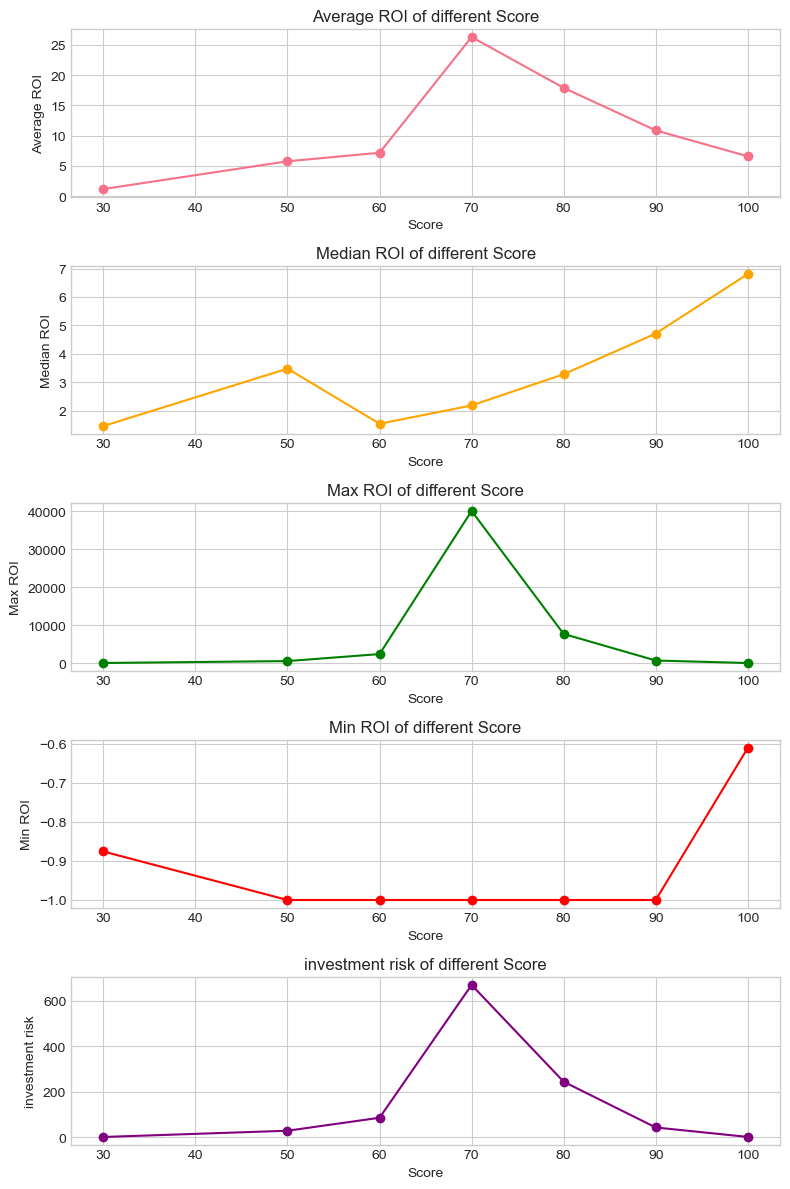

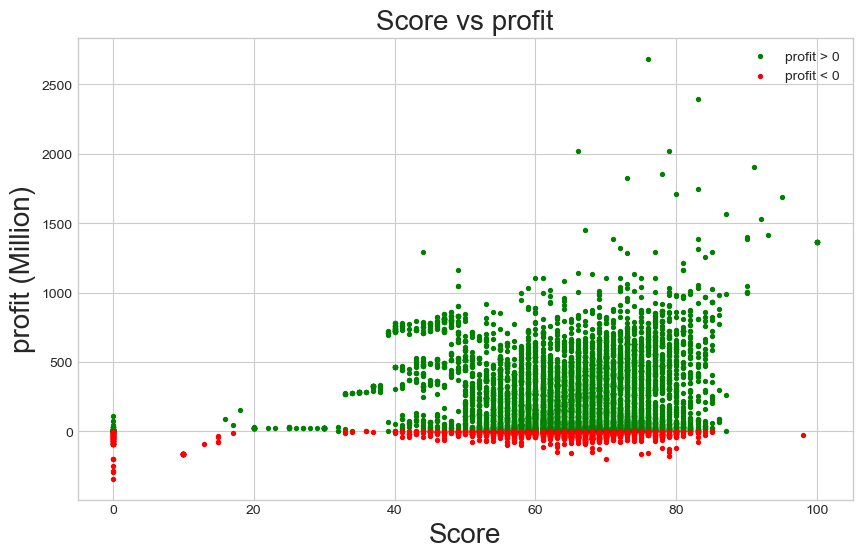

In [98]:
ROI_of_score()
Plot_of_ScoreVSProfit()

## Objective 2: To analyse the relationship between budget and profit
### Explanation of Results

This analysis examines how film budget shapes financial outcomes, using two scatter plots to reveal overall patterns and investment risks. The results show that while higher budgets can unlock greater profit potential, they also amplify the chance of substantial loss. By incorporating mean budget and mean profit as reference lines, we categorize films into four strategic quadrants, enabling a clearer evaluation of cost-effectiveness, risk exposure, and return patterns across the industry.

The first scatter plot illustrates the relationship between film budget (x-axis) and profit (y-axis). Each point represents an individual film: green dots indicate profitable films (profit > 0), red dots indicate films that incurred losses (profit < 0). There is a weak positive correlation between budget and profit. Higher budgets correspond to a higher potential ceiling of profit, although this does not guarantee success. Budget-heavy films are more likely to achieve extremely high profits, but the risks also increase accordingly. Most films fall within the mid-to-low budget range (50–150 million USD). Both profitable and unprofitable films widely appear within this segment. Loss-making films appear across all budget levels. A high budget does not eliminate the risk of failure; instead, failures at high budgets often result in larger financial losses. Profit values are highly dispersed, ranging from negative values to over 2.5 billion USD. This demonstrates that profitability depends on many external factors beyond budget.

The second chart shows the relationship between film budget (x-axis) and profit (y-axis). Two dashed lines mark the mean_budget and mean_profit. These boundaries divide the scatter plot into four quadrants for categorizing different investment–return patterns. In the scatter plot: green dots represent profitable films, red dots represent films operating at a loss. Films in upper left quadrant have below-average budgets and above-average profits. These are highly cost-effective films, often representing the king of Cost-effectiveness.  Films in upper right quadrant have above-average budgets and above-average profits. Despite higher financial risk, they produce the largest absolute profits. These are star project. Films in lower left quadrant have below-average budgets but also below-average profits. Although the financial risk is limited, the returns are modest. Belonging to mediocre films. The least desirable quadrant: films with high budgets but low or even negative profits. This represents high financial risk and poor returns, which called money-consuming trap. 

### Visualisation

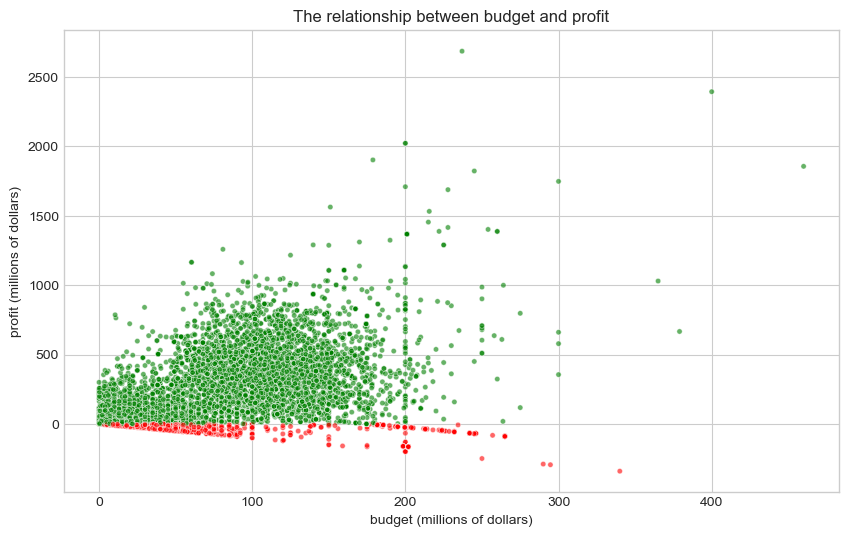

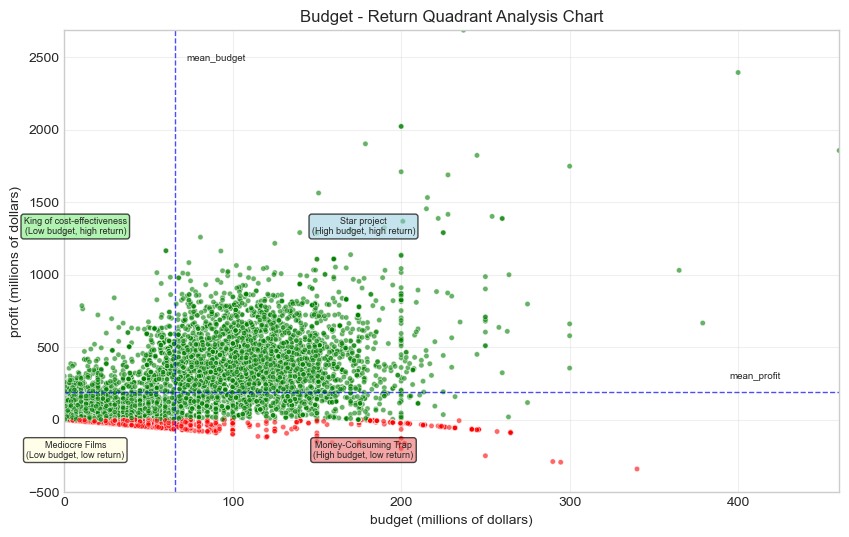

In [100]:
profit_of_film(df)
budget_profit_scatter(df)
budget_profit_quadrant(df)

## Objective 3: To evaluate the profitability of different release periods

For this objective, the aim was to identify the most financially ideal time of the year to release a film, based on historical box office performances. This knowledge is fiitting for investors and production companies, becuase timing is an important strategic decsion that can drastically affect revenue. By using the IMDB dataset, an analysis was carried out on how monthly release patterns are connected with worldwide box office returns.

To start the anaylsis, the raw_release_data column was converted into a suitable datetime format using day-first interpretation. From this formatted date, then the release month was extracted as an integer between 1 and 12. This changed the month column from a cluster of thousands of films into meaningful groups, making it possible to compare revenue performance across the year.

The summer months (May-August), which are often connected with blockbuster performances, showed relatively moderate and consistant median revenue levels. While typically these months do show strong performance potential, these were not the highest in this dataset. alternatively, December whcih is often considered a high-performing month because of the holiday period, showed one of the lowest median revenues in the dataset. This could suggest that either the films released in DEcember are more likely to be variable or that competition might dilute the box office earning potential.

The genre-specific analysis across months didn't reveal any consistant, interpretable trends. The genre by month visualisation produced showed high discrepancy and overlapping lines, which could imply that genre effects are less dependent on the season of the year, and are more influenced by other factorm, for instance, the marketing strategy used or target demographics.

To conclude, this dataset suggests that March offers the best financial opportunity, followed by January and February, whereas traditional ideas about releasing films in the summer months may not hold true for all titles. These findings provide valuable evidence for investors to consult when planning release schedules.

### Visualisation

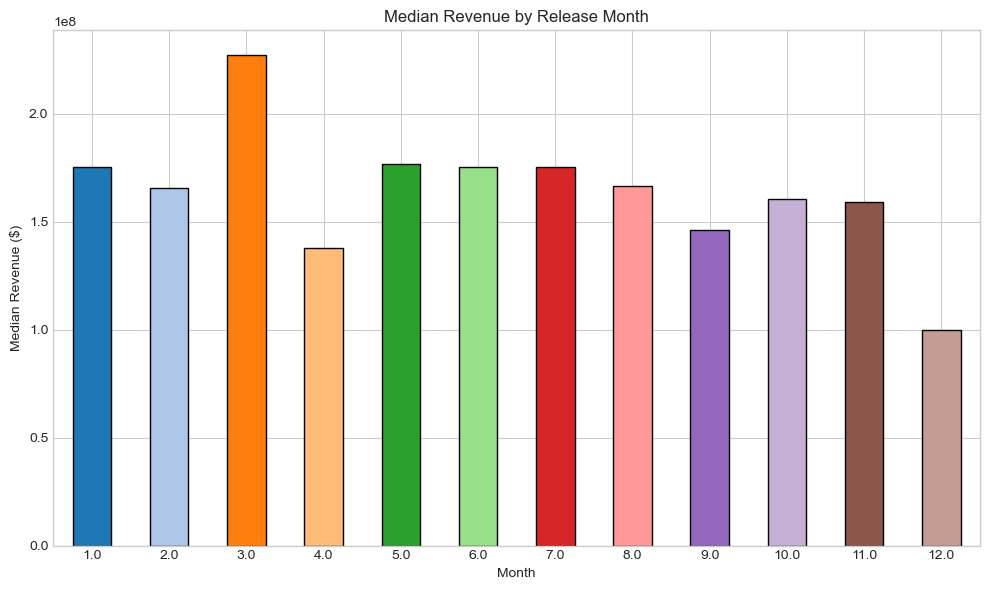

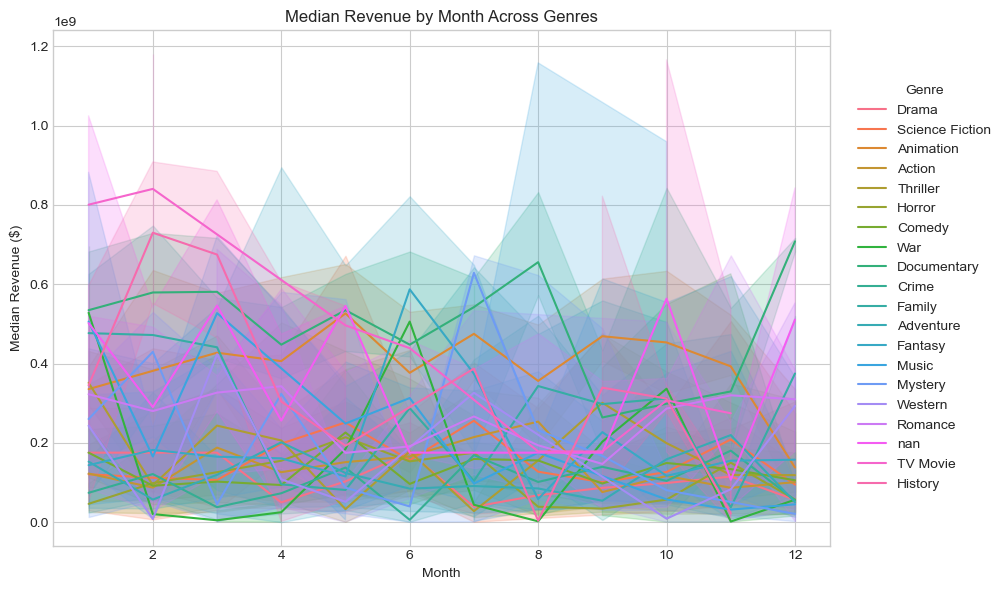

In [102]:
prepare_release_features(df)
plot_monthly_median_revenue(df)
plot_revenue_genre_month(df)

## Objective 4: Analysis the role of film genre in box office performance

Based on the comprehensive analysis of Average Profit and Average ROI of different movie types, the following systematic business conclusions can be drawn. The data shows that movie type not only determines the audience structure and cost model, but also significantly affects the level of investment risk and return. Therefore, it is of great value to study the commercial performance of movies from the perspective of genre.

First of all, from the perspective of Profit, Documentary and TV Movie perform the most prominently among all genres, with average profits significantly higher than other genres. The main reason is that they usually have extremely low production costs and can obtain stable income through specific channels. Animation, Family and Music also show high profitability. These genres have a broader audience base and stronger international market penetration, so they have continued commercial appeal.

However, when viewed from an ROI perspective, the results present a completely different picture. Action and Horror are the two types of movies with the highest ROI. Horror, in particular, usually achieves high box office at a very low cost, while action can still achieve excellent return performance despite high investment due to its global market acceptance. Types such as Adventure, Animation, Science Fiction and Comedy are in the mid-to-high range of ROI. They are relatively stable in terms of market demand and box office performance, and are suitable for investors with medium risk appetite.

In addition, niche types such as Western and Crime are at low levels in both profit and ROI dimensions, reflecting limited market size and weak business potential. Although the average profit of documentaries is very high, the ROI is not dominant. This shows that the income distribution of this type is extremely uneven. A few blockbuster films significantly increase the overall profit, while the income of most documentaries is mediocre.

Based on the above findings, a core conclusion can be drawn: High profits and high ROI of movies do not appear at the same time. Behind each type are different investment logics and market mechanisms.

If the goal is to pursue high profit peaks, documentaries, TV movies, cartoons and other genres are more attractive. If the goal is to pursue a more stable and cost-effective return on investment, action movies and horror movies are the most advantageous choices. If it is necessary to balance risks and returns, animations, adventure films, science fiction films and comedies perform well in both dimensions and are relatively stable genres.

Generally speaking, film type is a key variable that affects commercial performance. Different types correspond to different audience coverage, production cost structures and market fluctuation characteristics. Investors should make more targeted investment decisions based on their own risk preferences and income goals, combined with type characteristics, to maximize box office returns and control potential losses.

### Visualisation

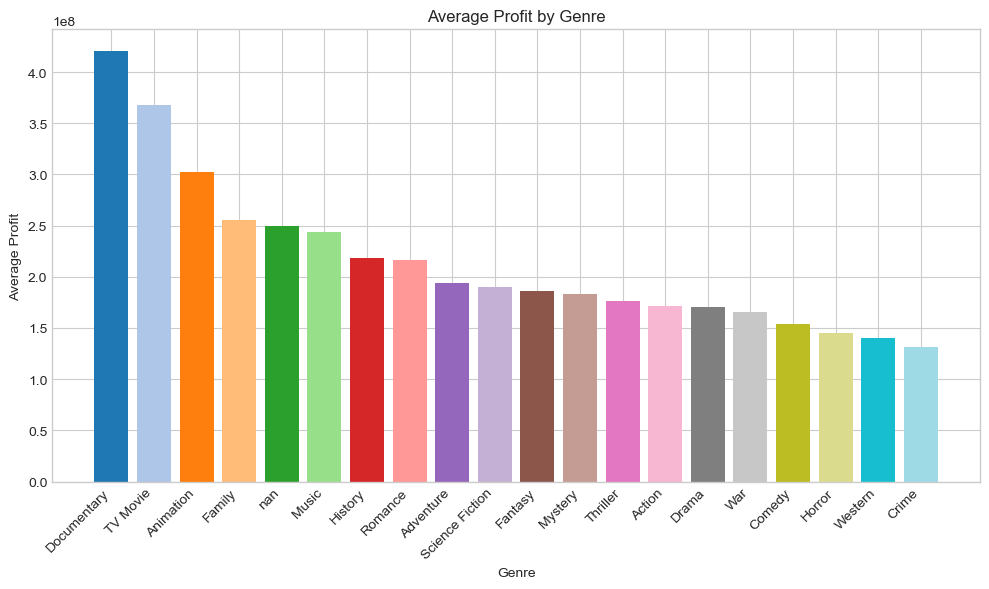

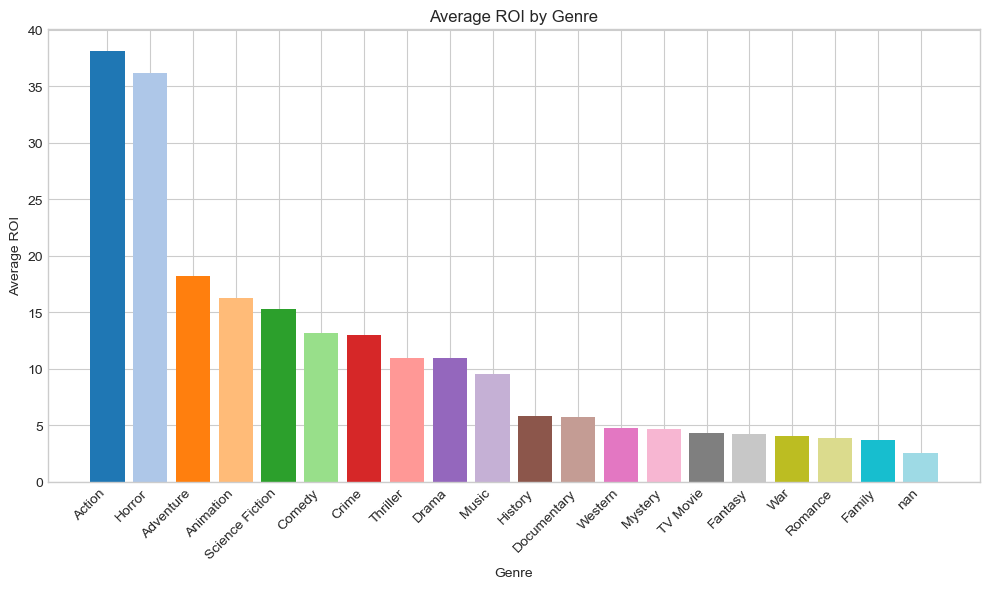

In [104]:
genre_stats = compute_genre_stats(df)
vis_avg_profit(genre_stats)
vis_avg_roi(genre_stats)

# Conclusion (5 marks)


### Achievements

This project successfully evaluated the financial factors of film investment including analyzing budget group with return, relationships of score and ROI, different theme, and monthly published patterns using dataset. In conclusion, from the results, the December period is a optional choice with a relatively higher return rate, but there are also form a competition with other films. As an alternative, summer period is also available, which are more stable to get a return. Besides, the score has less relationship with the ROI. However, for reducing the risk of the loss, it is still recommend to improve the quality of the film, making the score are around 70. Investors still need a balance between the quality and budget due to the high budget movies are both easy to get higher return and take higher risk of loss. In addition, the theme of the films can be selected in action, horror, adventure, animation and science fiction, which is widely acceptable.The project offers a evidence-based foundation to suggest film investors balance return potential with risk exposure.

### Limitations

While this research has many achievement, there are still many limitation. For example , distribution strategies, region culture are still not be considered. What’s more, movie merchandise, derivative works, copyright can also bring many profit, which may not be considered in the dataset but can take a big part of the return. In addition, the actors and the directors can bring more audience, which can bring more profit in some case.

### Future Work

Future work could refine the analysis by integrating multi-source datasets, including streaming performance, marketing spending, and social media sentiment to better model audience engagement and financial outcomes. Machine learning prediction models could be applied to estimate ROI more accurately using multidimensional features such as cast popularity, production companies, and franchise history. Additionally, future studies could explore cross-cultural differences in film consumption, investigate long-term profitability beyond theatrical release, and develop a decision-support tool that allows investors to simulate risks under different budget, genre, and release strategies.